# TSFS12 Hand-in Exercise 2: Planning for Vehicles with Differential Motion Constraints --- RRT with Particle Model

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from misc import Timer
from world import BoxWorld

In [3]:
%matplotlib inline
# %matplotlib  # Run instead if you want plots in external windows

In [ ]:
# Run the ipython magic below to activate automated import of modules. Useful if you write code in external .py files.
# %load_ext autoreload
# %autoreload 2

# Define the Planning World

Define world with obstacles

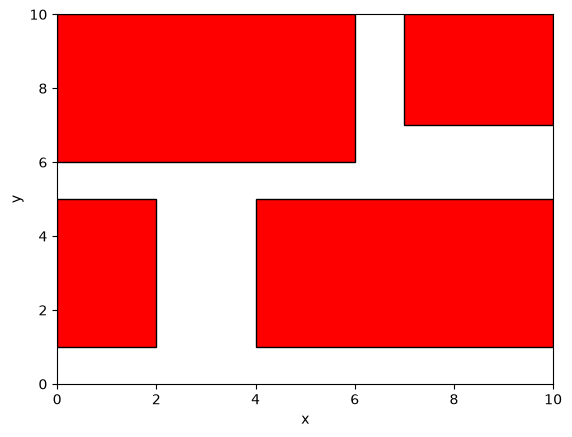

In [4]:
world = BoxWorld([[0, 10], [0, 10]])
world.add_box(0, 1, 2, 4)
world.add_box(0, 6, 6, 4)
world.add_box(4, 1, 6, 4)
world.add_box(7, 7, 3, 3)

_, ax = plt.subplots(num=10, clear=True)
world.draw()
ax.set_xlabel('x')
ax.set_ylabel('y')
_ = ax.axis([world.xmin, world.xmax, world.ymin, world.ymax])

# Implementation of RRT

Implementation of the RRT planning algorithm for a particle moving in a plane (2D world)

In [7]:
def rrt_particle(start, goal, world, opts):
    """RRT planner for particle moving in a 2D world
    
    Input arguments:
     start - initial state
     goal - desired goal state
     world - description of the map of the world
             using an object from the class BoxWorld
     opts - structure with options for the RRT
    
     Output arguments:
     goal_idx - index of the node closest to the desired goal state
     nodes - 2 x N matrix with each column representing a state j
             in the tree
     parents - 1 x N vector with the node number for the parent of node j 
               at element j in the vector (node number counted as column
               in the matrix nodes)
     Tplan - the time taken for computing the plan        
    """
    rg = np.random.default_rng()  # Get the default random number generator

    def sample_free():
        """Sample a state x in the free state space"""
        if rg.uniform(0, 1, 1) < opts['beta']:
            return np.array(goal)
        else:
            found_random = False
            while not found_random:
                x = (rg.uniform(0, 1, 2) * [world.xmax - world.xmin, world.ymax - world.ymin] + 
                     [world.xmin, world.ymin])
                if world.obstacle_free(x[:, None]):
                    found_random = True
            return x

    def nearest(x):
        """Find index of state nearest to x in the matrix nodes"""        
        idx = np.argmin(np.sum((nodes - x[:, None])**2, axis=0))
        return idx
    
    def steer(x1, x2):
        """Steer from x1 towards x2 with step size opts['lambda']
        
        If the distance to x2 is less than opts['lambda'], return
        state x2.
        """
        dx = np.linalg.norm(x2 - x1)
        if dx < opts['lambda']:
            x_new = x2
        else:
            x_new = x1 + opts['lambda'] * (x2 - x1) / dx
        return x_new
    
    # Start time measurement and define variables for nodes and parents
    T = Timer()
    T.tic()
    nodes = start.reshape((-1, 1))  # Make numpy column vector
    parents = [0]   # Initial state has no parent

    # YOUR CODE HERE

    # Kör maximalt K iterationer
    for k in range(opts['K']):

        # STEG 1 - sample
   
        # Slumpa en fri punkt
        x_rand = sample_free()

        #steg 2 - nearest

        # Hitta närmaste nod i trädet
        idx_near = nearest(x_rand)

        # Hämta koordinaterna för denna nod
        x_near = nodes[:, idx_near]

        # STEG 3: STEER
        #steg 3 -steer

        # Ta ett steg mot den slumpade punkten
        x_new = steer(x_near, x_rand)


        #steg 4 - kollisionskontrolll

        # Skapa flera punkter mellan 0 och 1
        # De används för att testa hela linjen
        alpha = np.linspace(0, 1, 20)

        # Skapa punkter längs linjen mellan x_near och x_new
        path_points = (
            x_near[:, None] * (1 - alpha)[None, :]
            + x_new[:, None] * alpha[None, :]
        )

        # Kontrollera att alla punkter längs vägen är fria
        collision_free = np.all(
            world.obstacle_free(path_points)
        )

        # steg 5 - lägg till nod

        # Endast om hela vägen är kollisionsfri
        if collision_free:

            # Lägg till x_new som ny kolumn i nodes
            nodes = np.column_stack(
                (nodes, x_new)
            )

            # Spara att den nya nodens parent är idx_near
            parents.append(idx_near)

            # steg 6 - kontrollera goal

            # Om eps är positiv får algoritmen avsluta tidigt
            if opts['eps'] > 0:

                # Beräkna avstånd från den nya noden till goal
                distance_to_goal = np.linalg.norm(
                    x_new - goal
                )

                # Om vi är närmare än eps
                if distance_to_goal < opts['eps']:

                    # Avsluta RRT
                    break
    
    Tplan = T.toc()
    goal_idx = np.argmin(np.sum((nodes - goal.reshape((-1, 1)))**2, axis=0))
    
    return goal_idx, nodes, parents, Tplan

Run the planner

In [9]:
start = np.array([1, 0]) # Start state
goal = np.array([6.5, 9]) # Goal state

opts = {'beta': 0.05,  # Probability of selecting goal state as target state in the sample
        'lambda': 0.1,  # Step size
        'eps': -0.01,  # Threshold for stopping the search (negative for full search)
        'K': 5000}     # Maximum number of iterations, if eps < 0

print('Planning ...')
idx_goal, nodes, parents, Tplan = rrt_particle(start, goal, world, opts)
print('Finished in {:.2f} s'.format(Tplan))


path_indices = []

idx = idx_goal
path_indices.append(idx)

while idx != 0:
    idx = parents[idx]
    path_indices.append(idx)

path_indices.reverse()

path = nodes[:, path_indices]

Planning ...
Finished in 0.50 s


# Plots and Analysis

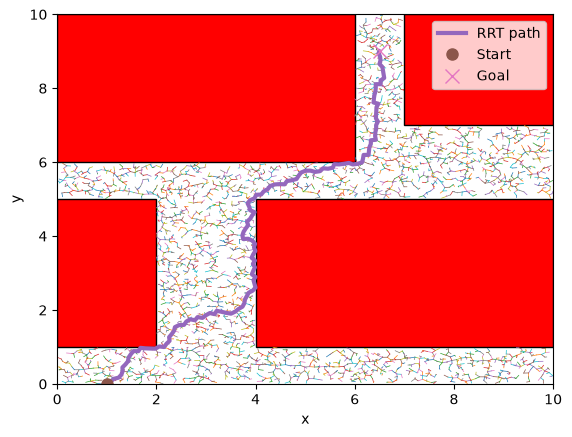

In [10]:
# Hint on plotting: To plot the path corresponding to the found solution,
# the following code could be useful (utilizing backtracking from the goal 
# node:
#
# drawlines = []
# idx = idx_goal
# while idx != 0:
#     ll = np.column_stack((nodes[:, parents[idx]], nodes[:, idx]))
#     drawlines.append(ll[0])
#     drawlines.append(ll[1])
#     idx = parents[idx]
# _, ax = plt.subplots(num=99, clear=True)
# ax.plot(*drawlines, color='b', lw=2)

# plottar rrt trädet och vägen

# Skapa en ny figur
_, ax = plt.subplots(num=20, clear=True)

# Rita världen och hindren
world.draw()

# ritar rrt trädet

# Börja på nod 1 eftersom nod 0 är startnoden
# och inte har någon riktig parent
for i in range(1, nodes.shape[1]):

    # Hämta index för nodens parent
    parent_idx = parents[i]

    # x-koordinater för parent och nuvarande nod
    x_values = [
        nodes[0, parent_idx],
        nodes[0, i]
    ]

    # y-koordinater för parent och nuvarande nod
    y_values = [
        nodes[1, parent_idx],
        nodes[1, i]
    ]

    # Rita en linje mellan parent och nod
    ax.plot(
        x_values,
        y_values,
        linewidth=0.5
    )

# rita den hittade vägen från start mot goal

ax.plot(
    path[0, :],      # alla x-koordinater längs vägen
    path[1, :],      # alla y-koordinater längs vägen
    linewidth=3,
    label='RRT path'
)


# rita startpunkten

ax.plot(
    start[0],        # startens x-koordinat
    start[1],        # startens y-koordinat
    'o',
    markersize=8,
    label='Start'
)


# rita goal - målet

ax.plot(
    goal[0],         # goals x-koordinat
    goal[1],         # goals y-koordinat
    'x',
    markersize=10,
    label='Goal'
)


# figurinställningar

# Namn på x-axeln
ax.set_xlabel('x')

# Namn på y-axeln
ax.set_ylabel('y')

# Begränsa figuren till världens storlek
ax.axis([
    world.xmin,
    world.xmax,
    world.ymin,
    world.ymax
])

# Visa legend
ax.legend()

# Visa figuren
plt.show()